# Run Model

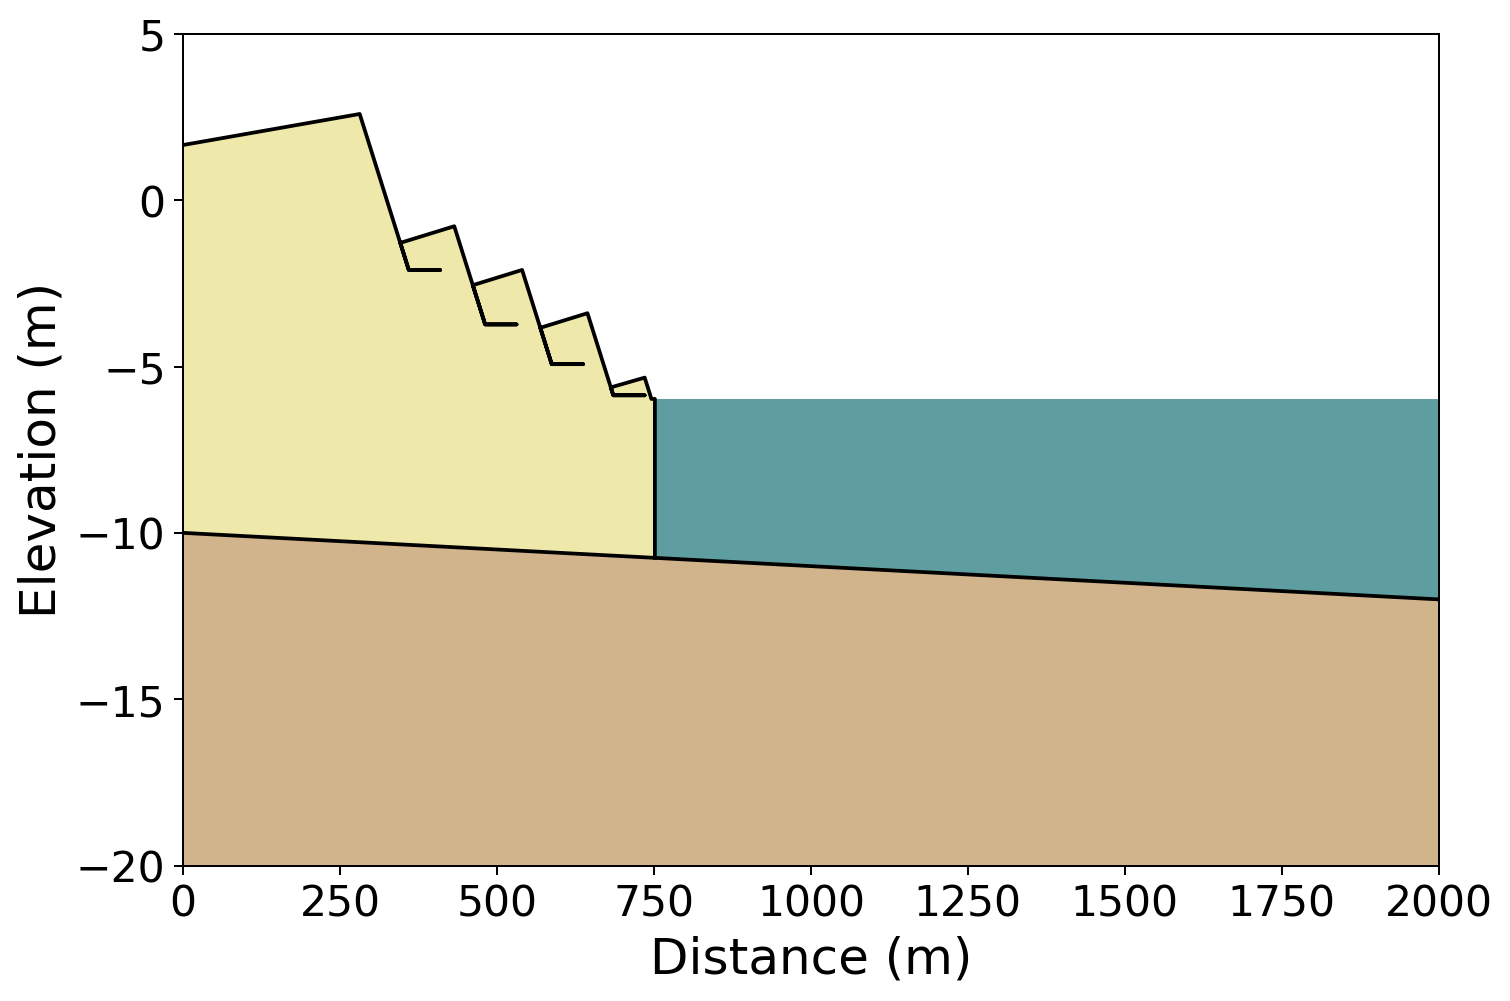

In [1]:
from beachridge_plot import swash_wash

a=-.002 # #relative sea level (m/yr)
m=0.001 # beach platform slope (m/m)
Qr=1 # sediment flux from shoreline to ridge (m3/m/yr)
Qs=2 # sediment flux to the shoreline (m3/m/yr)
Tmax=3000 # total model runtime (yrs)
dt=1 # timestep (yrs)
b=10 # starting water depth (m)
maxH=3 # maximum ridge height (m)
maxdis = 50 #maximum distance wave runup for ridge nucleation
atrigger=Tmax-12 #Set the the interval to capture frames for animation
title= 'model_run' # names to save image under
saveimage = False # set to true if want images saved
type_of_image = False # which parameter are you testing: RSL, sed, or slope

swash_wash(Qr,Qs,Tmax,dt,m,a,b,maxH,maxdis,atrigger,title,type_of_image,saveimage)

# Run Model with Different RSL, Slope, Sed Values

In [2]:
from beachridge_plot import swash_wash

Tmax=3000 # total model runtime (yrs)
dt=1 # timestep (yrs)
b=15 # starting water depth (m)
maxH=5 # maximum ridge height (n)
atrigger=Tmax-10 #Set the the interval to capture frames for animation
saveimage = False # set to true if want images saved
maxdis = 50 #maximum distance wave runup for ridge nucleation

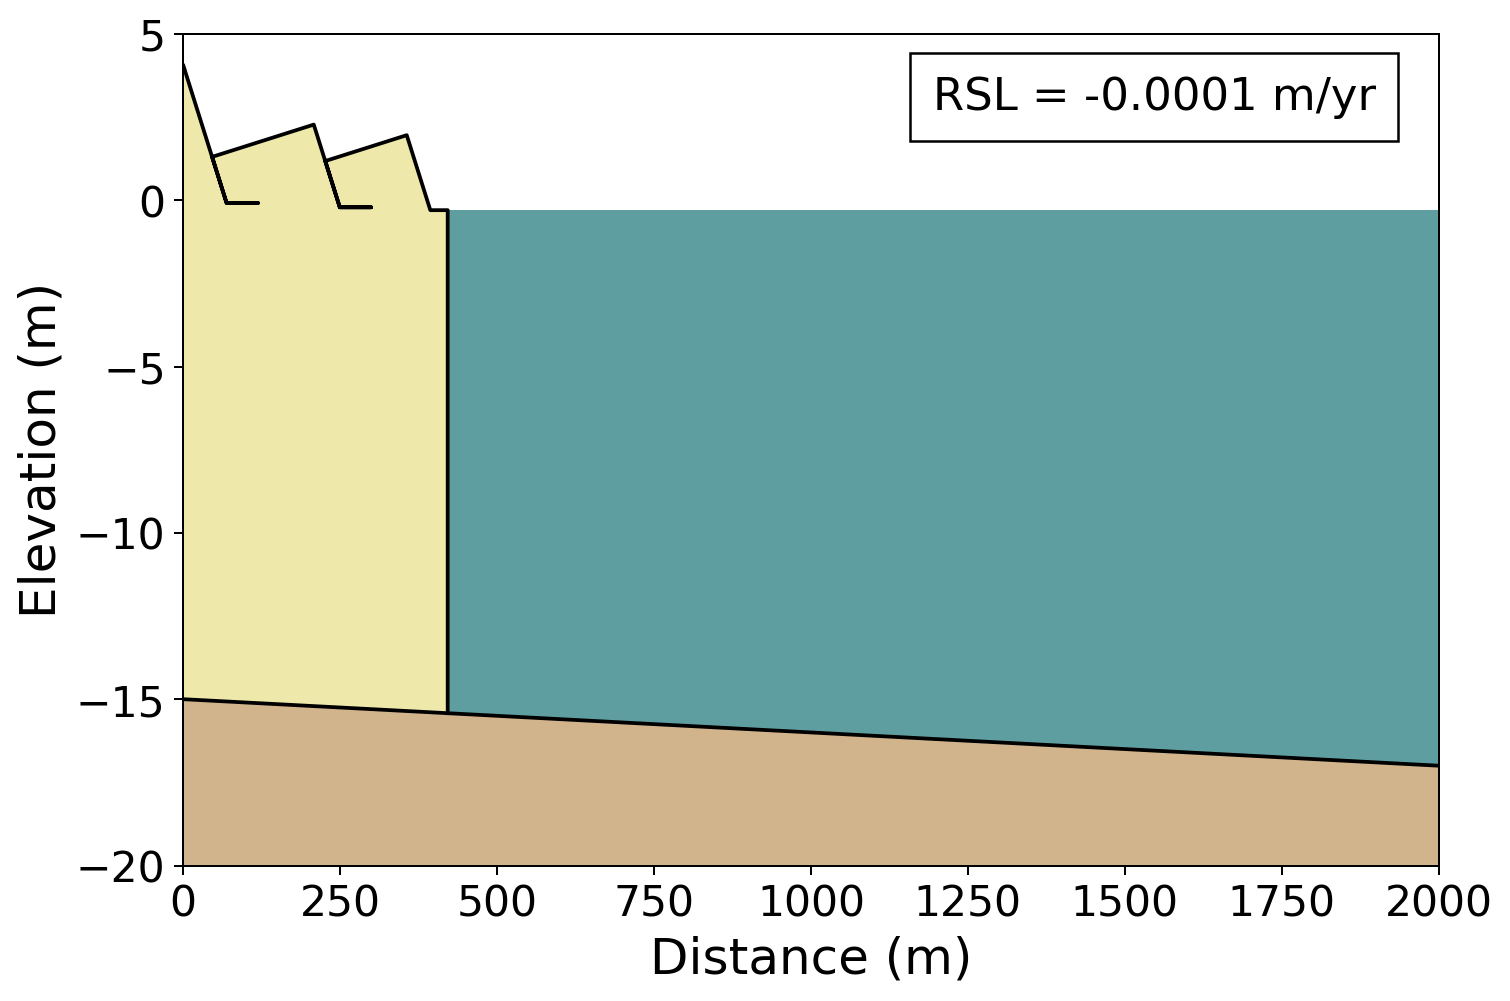

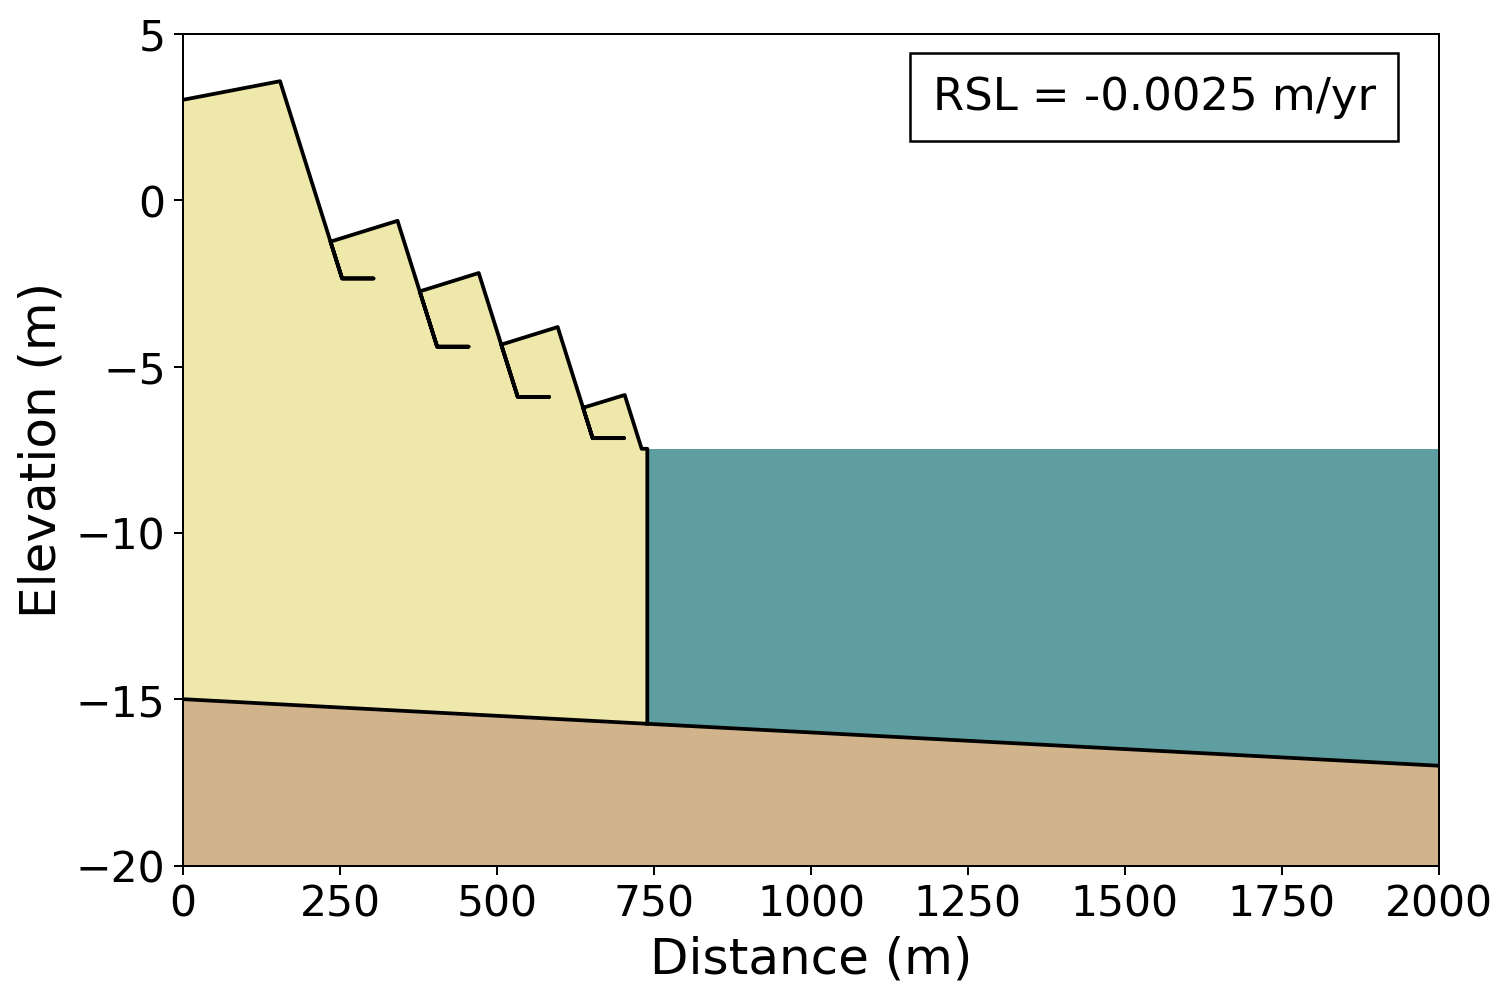

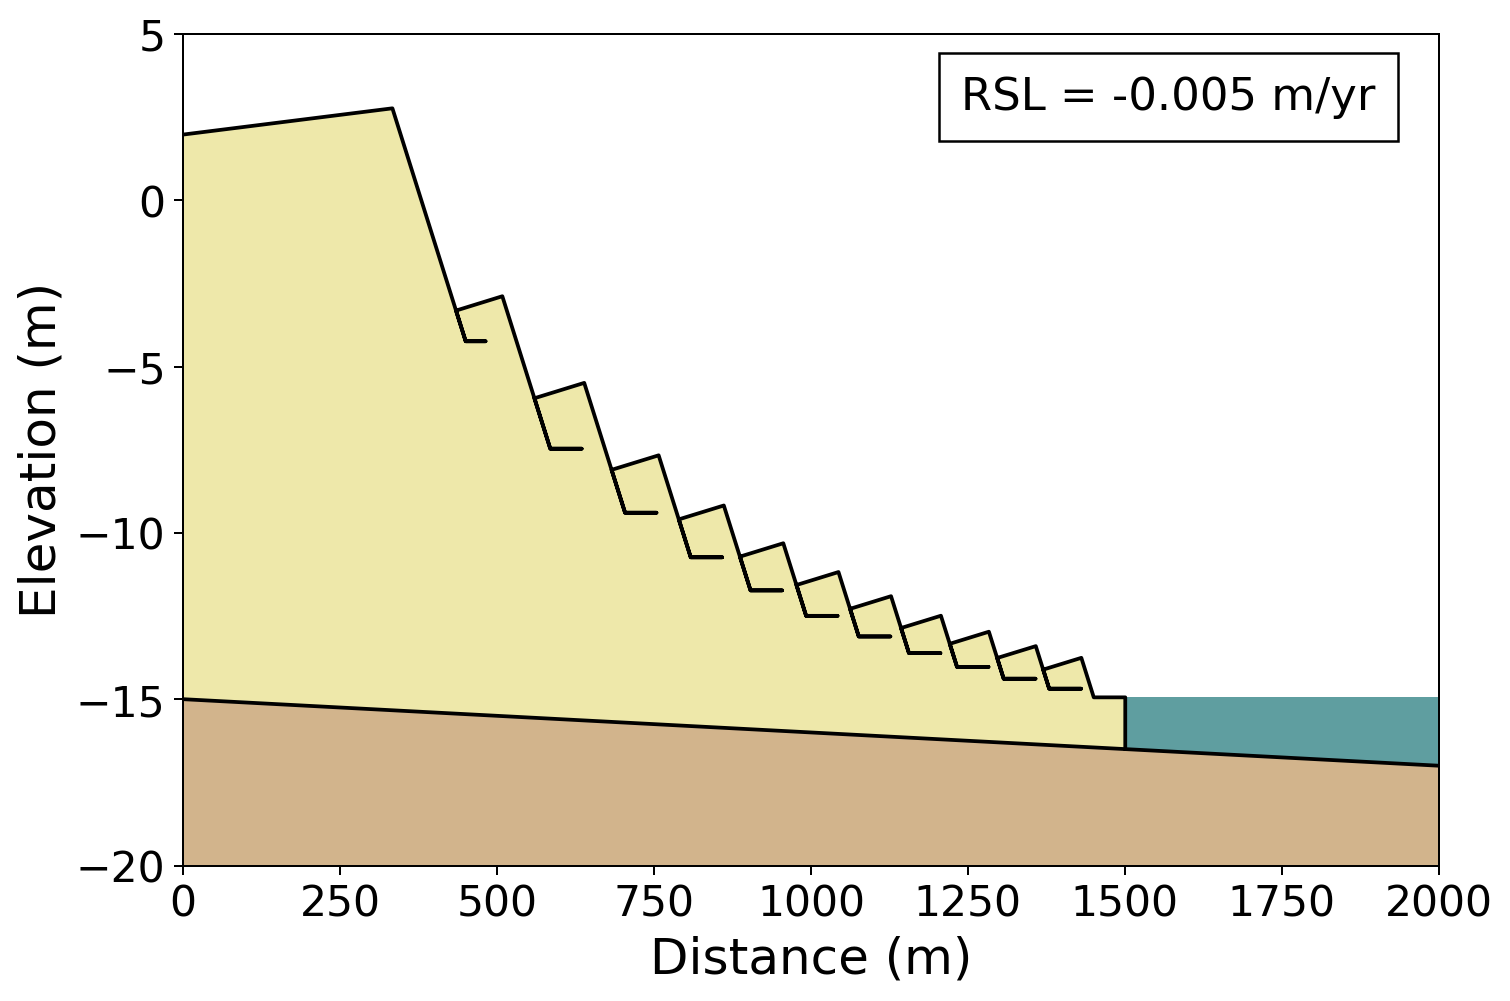

In [3]:
# run model for different rsl values
rsl_titles=['rsl0001','rsl001','rsl01'] # names to save images under
rsl_array=[-.0001,-.0025,-.005]

for i in range(0,len(rsl_array)):
    title = rsl_titles[i]
    a = rsl_array[i]
    m=0.001 # beach platform slope (m/m)
    Qr=2 # sediment flux from shoreline to ridge (m3/m/yr)
    Qs=4 # sediment flux to the shoreline (m3/m/yr)
    type_of_image='RSL'
    swash_wash(Qr,Qs,Tmax,dt,m,a,b,maxH,maxdis,atrigger,title,type_of_image,saveimage)

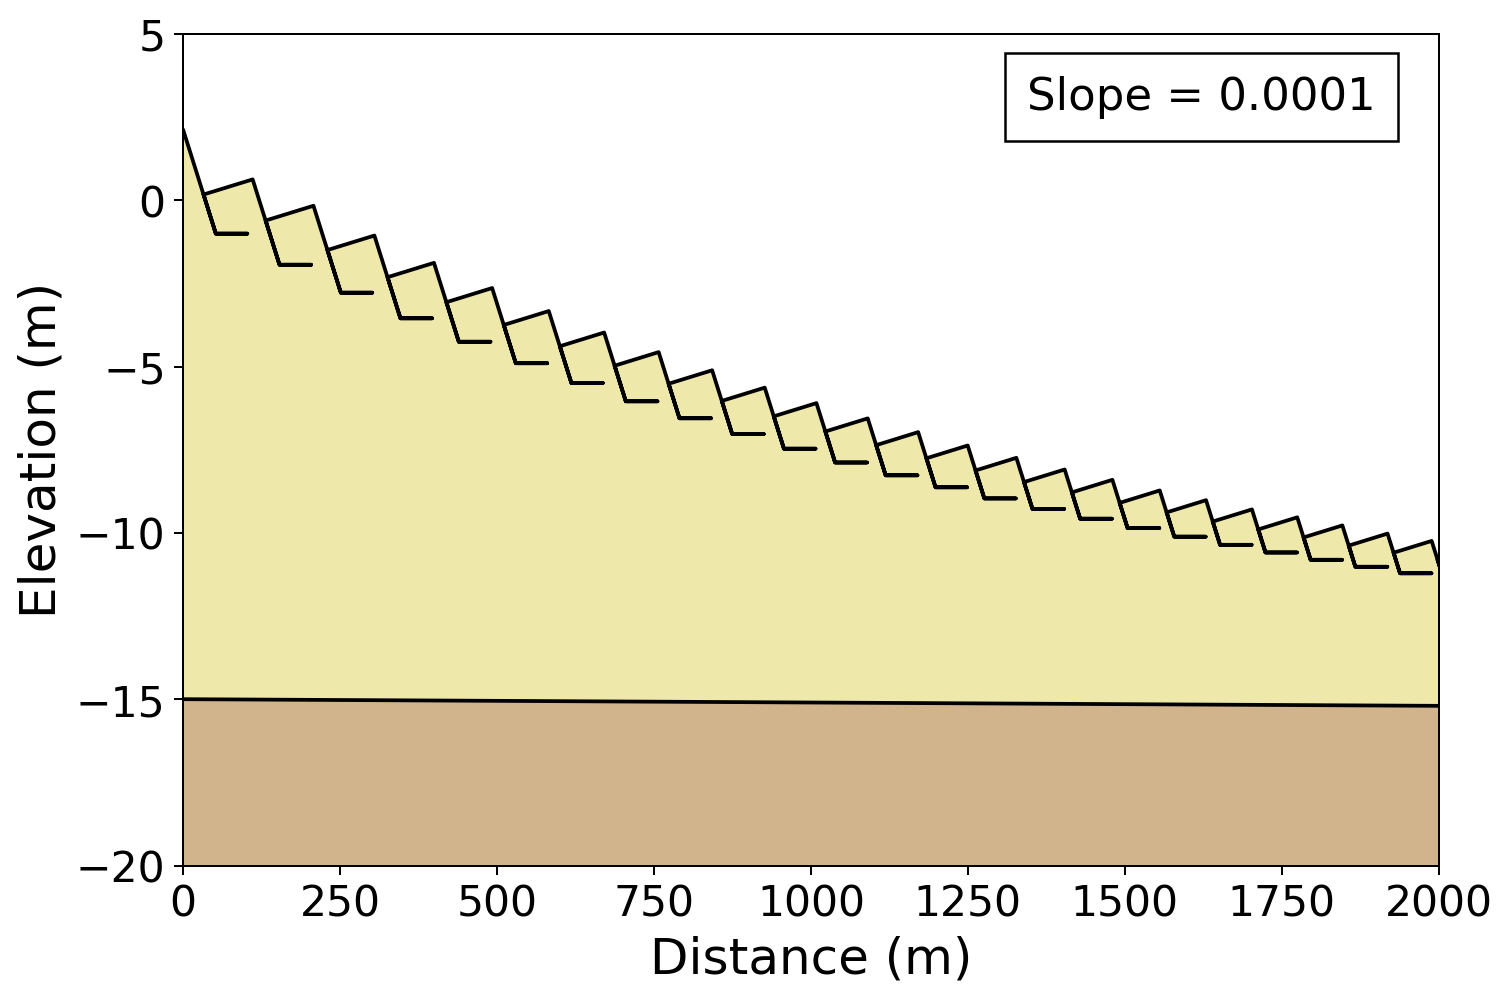

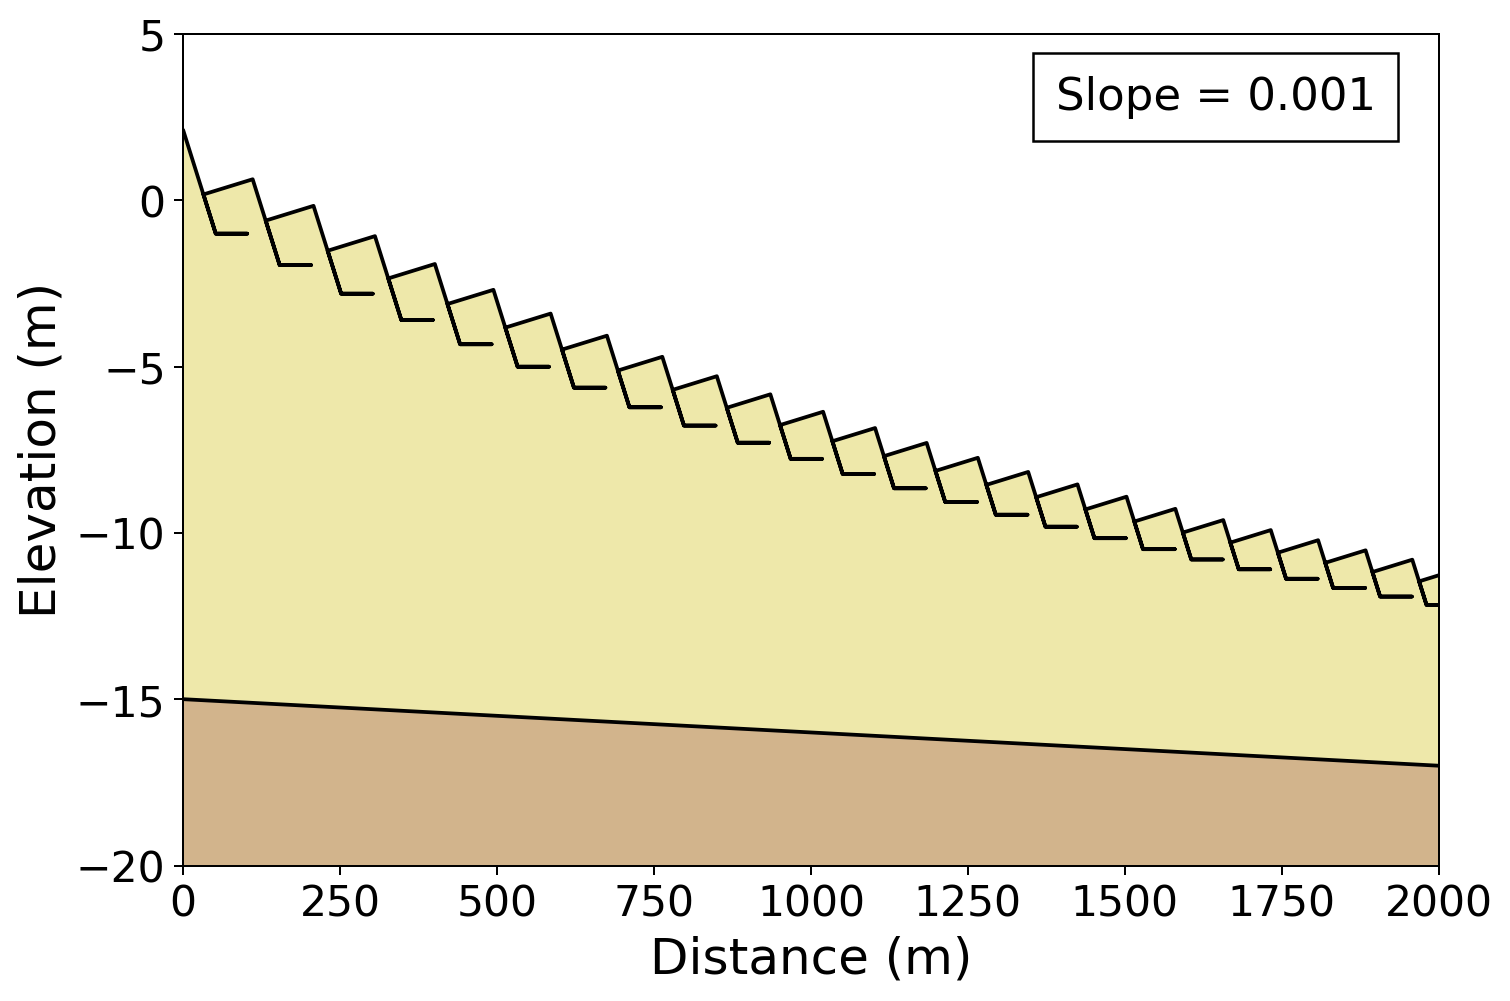

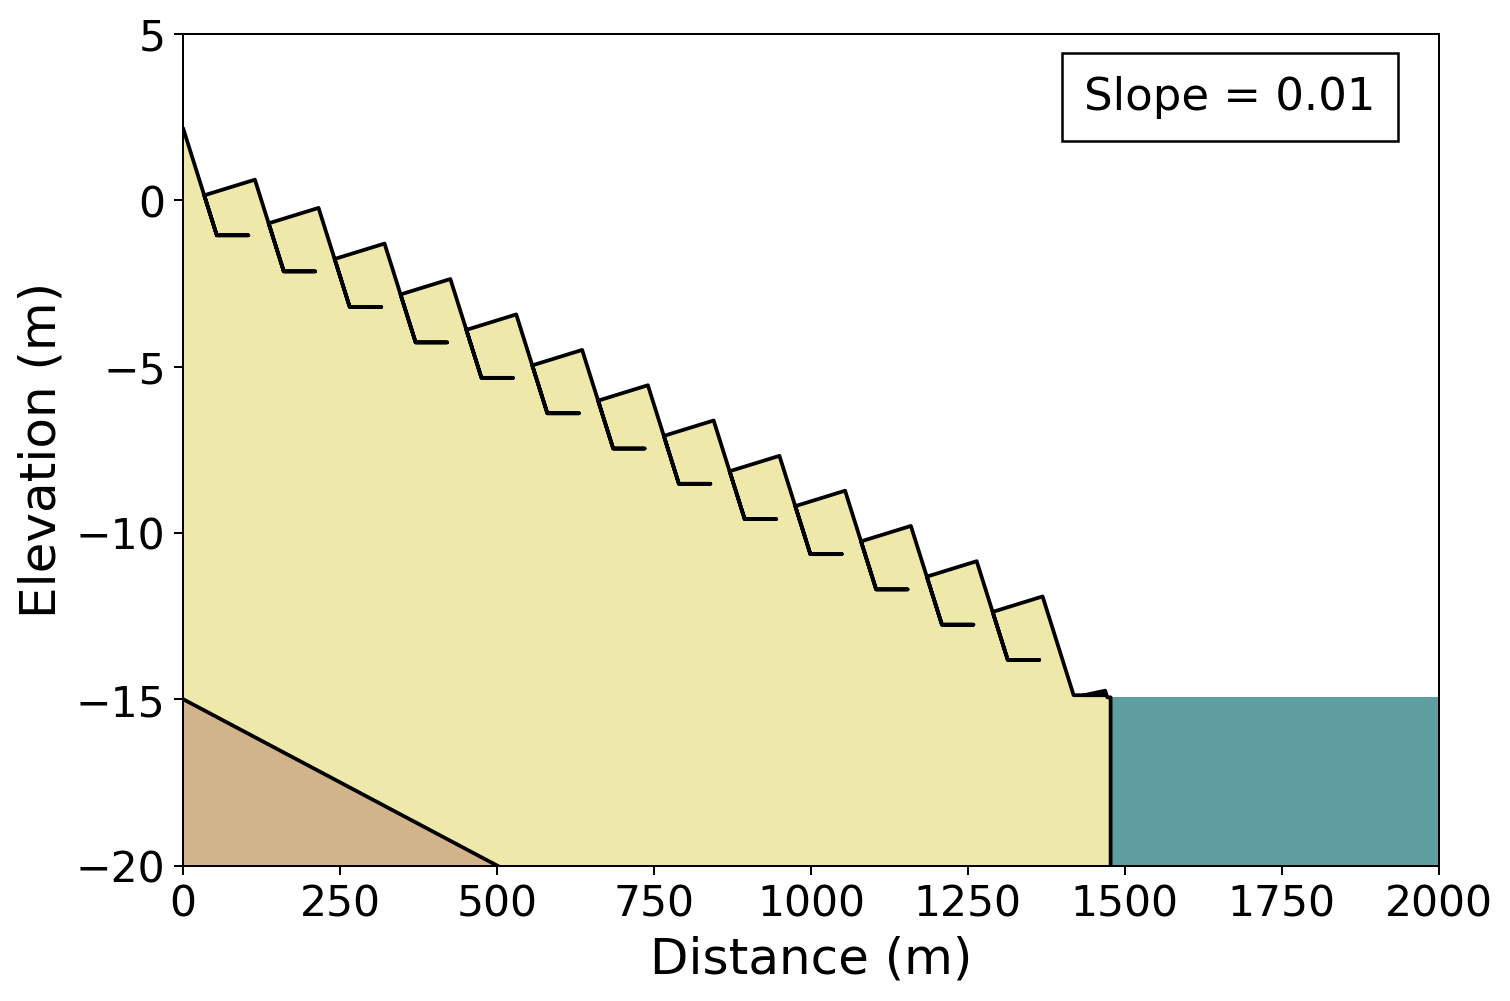

In [4]:
# run model for different slope values
slope_titles = ['small_slope.png','med_slope.png','large_slope.png'] # names to save images under
slope_array = [.0001,.001,.01]

for i in range(0,len(slope_array)):
    title = slope_titles[i]
    m = slope_array[i]
    RSL=-.002 #relative sea level (m/yr)
    Qr=3 #sediment flux from shoreline to ridge (m3/m/yr)
    Qs=10 #sediment flux to the shoreline (m3/m/yr)
    type_of_image='slope'
    swash_wash(Qr,Qs,Tmax,dt,m,a,b,maxH,maxdis,atrigger,title,type_of_image,saveimage)

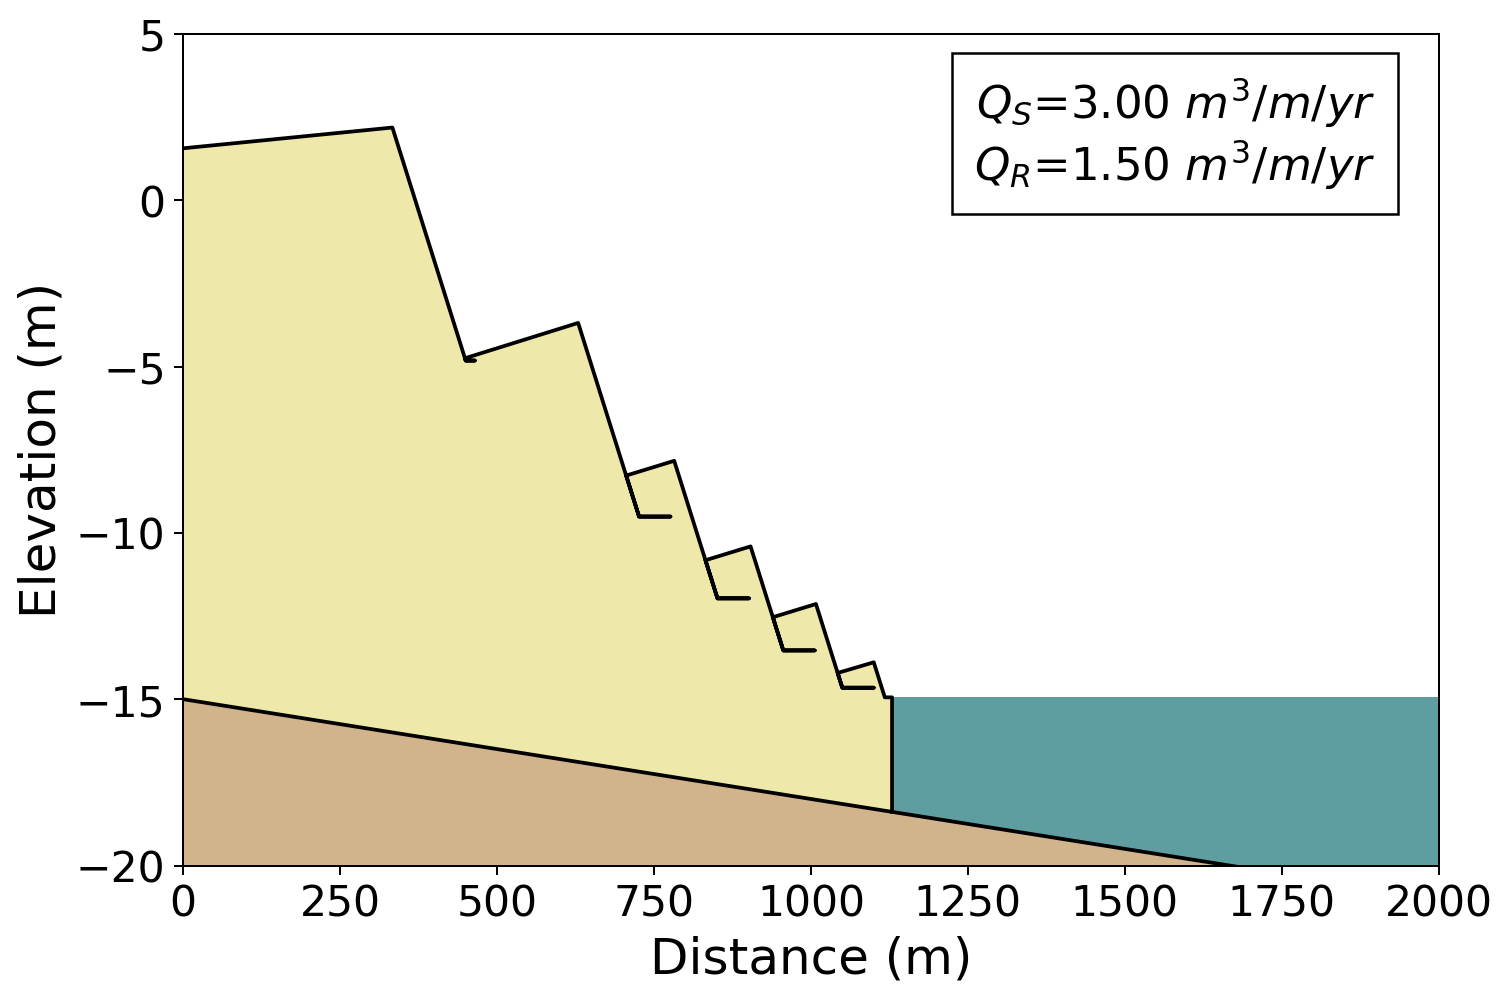

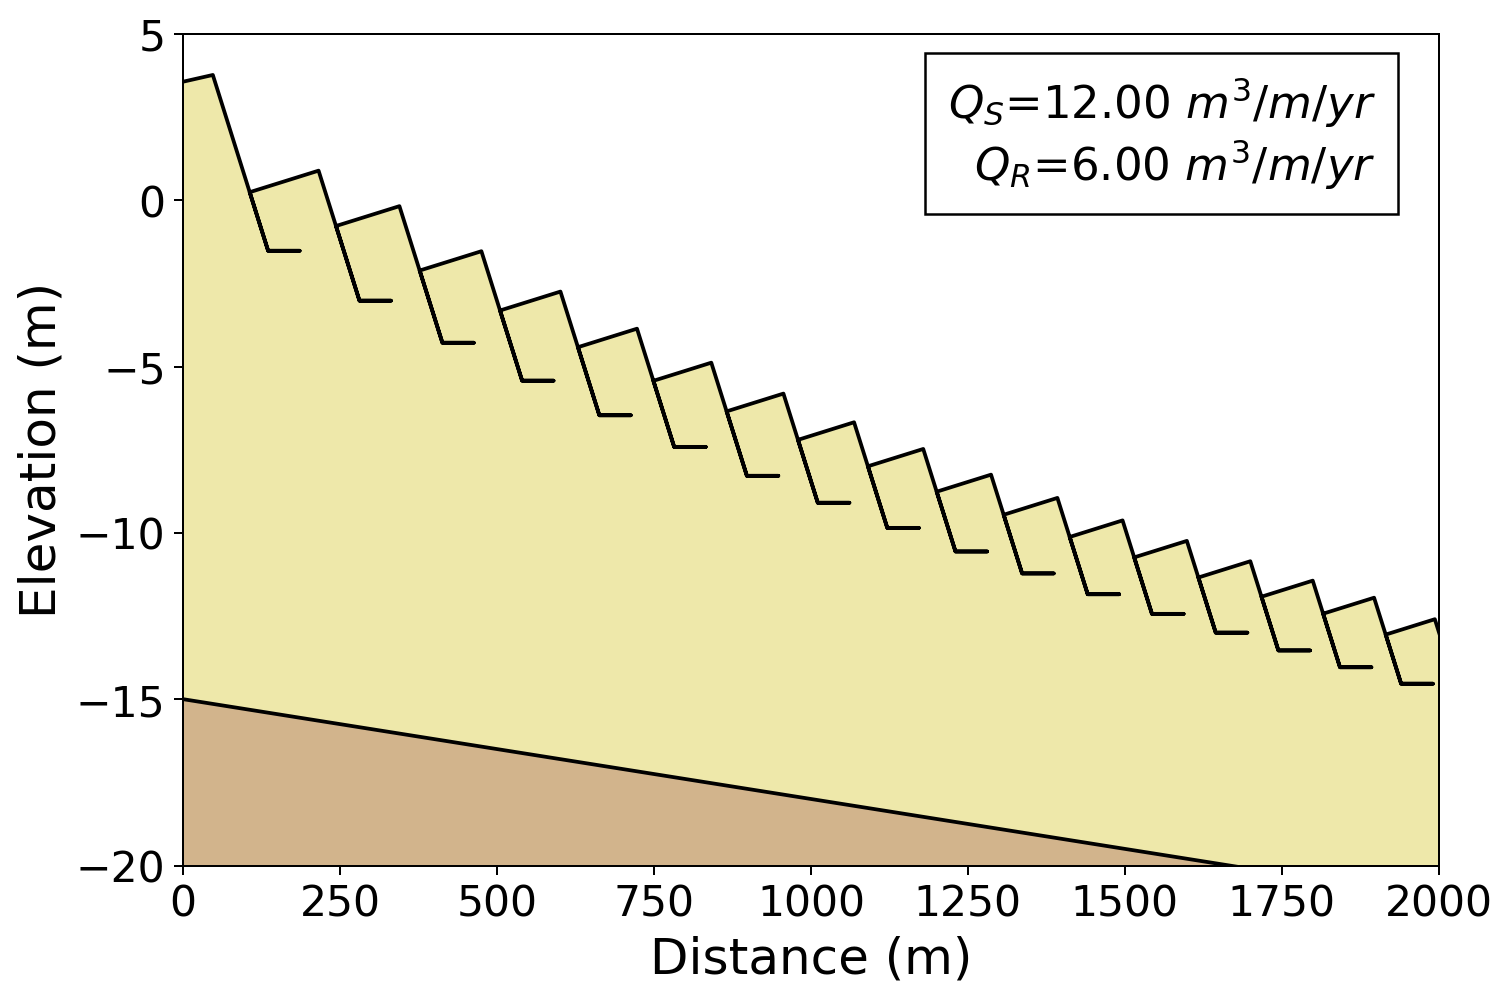

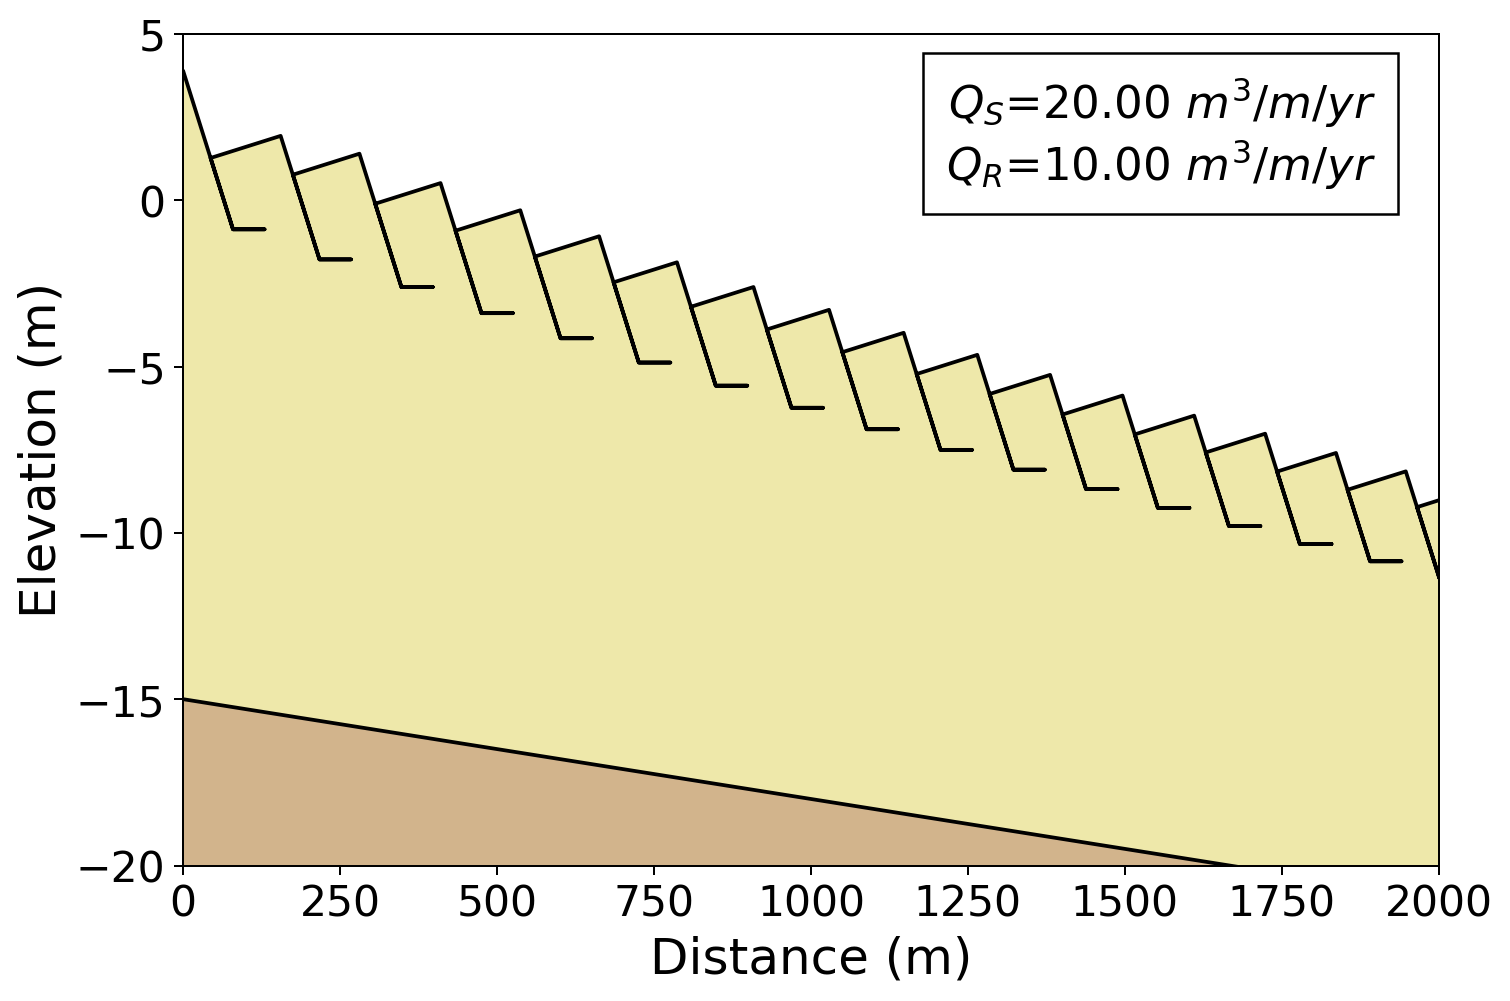

In [5]:
# run model for different sed values
sed_titles = ['small_sed.png','med_sed.png','large_sed.png'] # names to save images under
sedqs_array = [3,12,20]
sedqr_array = [1.5,6,10]

for i in range(0,len(sedqs_array)):
    title = sed_titles[i]
    Qs = sedqs_array[i]
    Qr = sedqr_array[i]
    m=.003 #beach platform slope (m/m)
    RSL=-.002 #relative sea level (m/yr)
    type_of_image='sed'
    swash_wash(Qr,Qs,Tmax,dt,m,a,b,maxH,maxdis,atrigger,title,type_of_image,saveimage)    

# Accomodation

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from ridge_parameter import swash_wash_params

def accomodation(a,Qr,Qs,Tmax,m,dt,b,maxH):
    
    Length, Height, RidgeCounter,time,depth=swash_wash_params(Qr,Qs,Tmax,dt,m,a,b,maxH)

    Height = np.array(Height)
    depth = np.array(depth)
    tim_loc_heights, _ = find_peaks(Height)
    loc_heights = Height[tim_loc_heights]
    accom = depth[tim_loc_heights]

    fig, ax1 = plt.subplots(figsize=(6,3))

    # --- Left axis: Height ---
    ax1.plot(tim_loc_heights, loc_heights, label="Height")
    ax1.set_xlabel("Time (years)",fontsize=14)
    ax1.set_ylabel("Ridge Height (m)", color='tab:blue',fontsize=14)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # --- Right axis: Accommodation ---
    ax2 = ax1.twinx()  # second y-axis sharing the same x
    ax2.plot(tim_loc_heights, accom, color='tab:red', label="Accomodation")
    ax2.set_ylabel("Accommodation (m)", color='tab:red',fontsize=14)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    fig.tight_layout()
    # fig.savefig("accom.png", dpi=300) 
    plt.show()

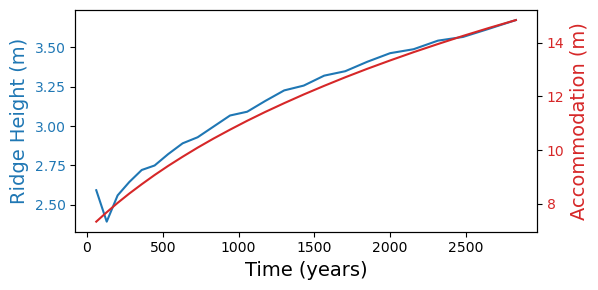

In [7]:
a=-.002 # relative sea level (m/yr)
Qr=10 # sediment flux from shoreline to ridge (m3/m/yr)
Qs=20 # sediment flux to the shoreline (m3/m/yr)
m=0.005 # beach platform slope (m/m)
Tmax=3000 # total model runtime (yrs)
dt=1 # timestep (yrs)
b=7 # starting water depth (m)
maxH = 5 # maximum ridge height (m)

accomodation(a,Qr,Qs,Tmax,m,dt,b,maxH)

# Results Images

In [25]:
from results_analysis import ModelAnalysis
import numpy as np

a=-.002 # relative sea level (m/yr)
Qr=1 # sediment flux from shoreline to ridge (m3/m/yr)
Qs=2 # sediment flux to the shoreline (m3/m/yr)
m=0.005 # beach platform slope (m/m)
Tmax=3000 # total model runtime (yrs)
dt=1 # timestep (yrs)
b=7 # starting water depth (m)
maxH = 5 # maximum ridge height (m)

analysis = ModelAnalysis(Tmax,dt,a,b,maxH,Qr,Qs,m)

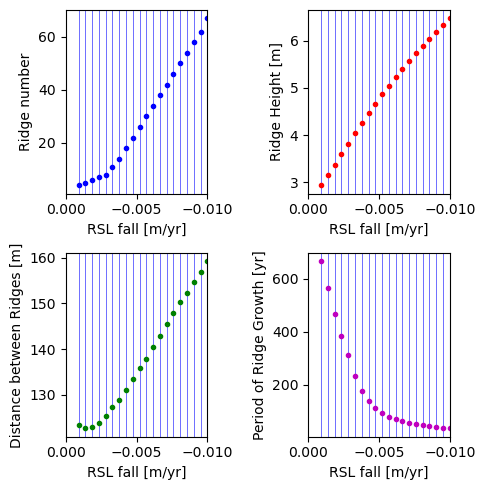

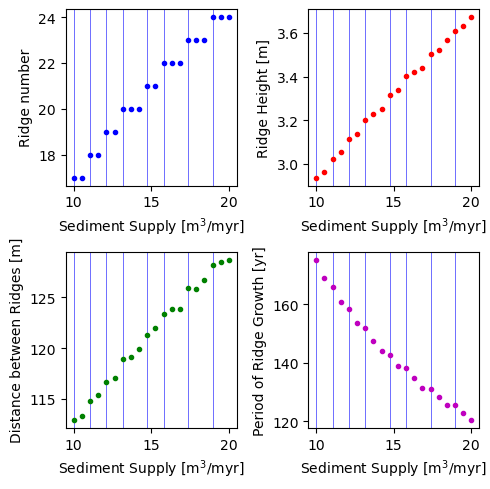

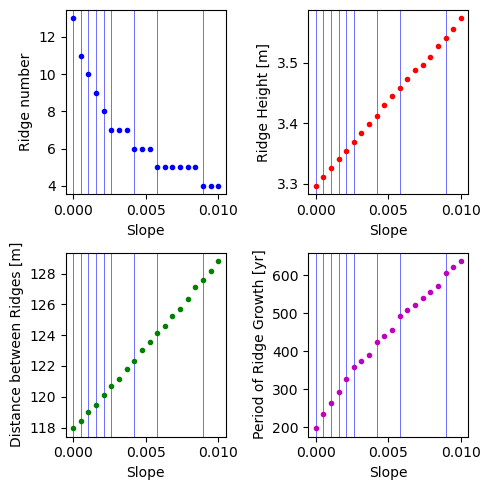

In [26]:
RSL = np.linspace(-.01,-.0009,20)
analysis.RSL_param_graphs(RSL)

sedsupQs=np.linspace(10,20,20)
sedsupQr = sedsupQs/2
analysis.sedsup_param_graphs(sedsupQs,sedsupQr)

m_vec = np.linspace(0,.01,20)
analysis.slope_param_graphs(m_vec)

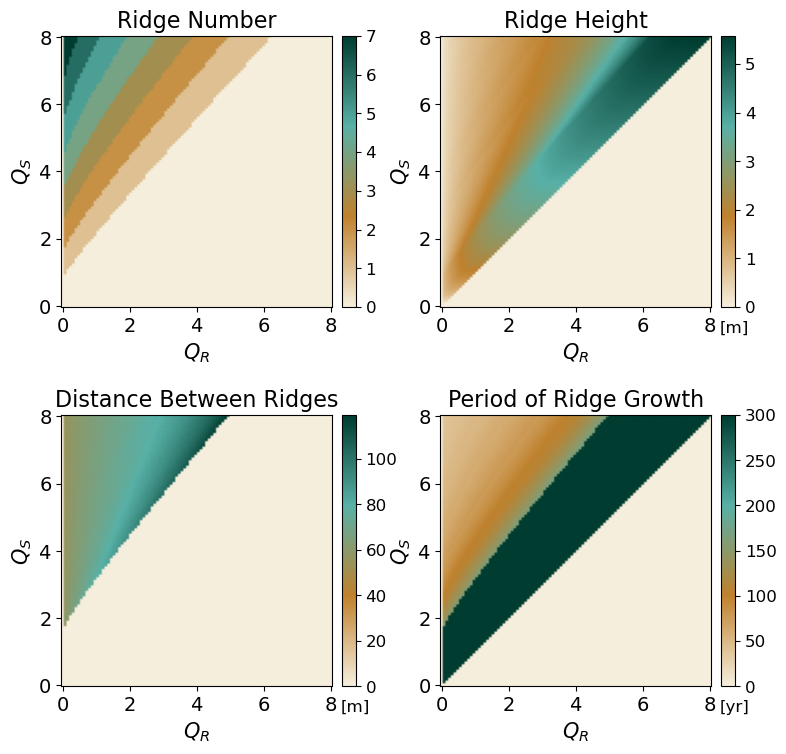

In [27]:
a=-.002 # relative sea level (m/yr)
Qr=1 # sediment flux from shoreline to ridge (m3/m/yr)
Qs=2 # sediment flux to the shoreline (m3/m/yr)
m=0.01 # beach platform slope (m/m)
Tmax=300 # total model runtime (yrs)
dt=1 # timestep (yrs)
b=5 # starting water depth (m)
maxH = 5 # maximum ridge height (m)

analysis = ModelAnalysis(Tmax,dt,a,b,maxH,Qr,Qs,m)

N=100 # specify pixel number
analysis.regime_plot_SS(N)

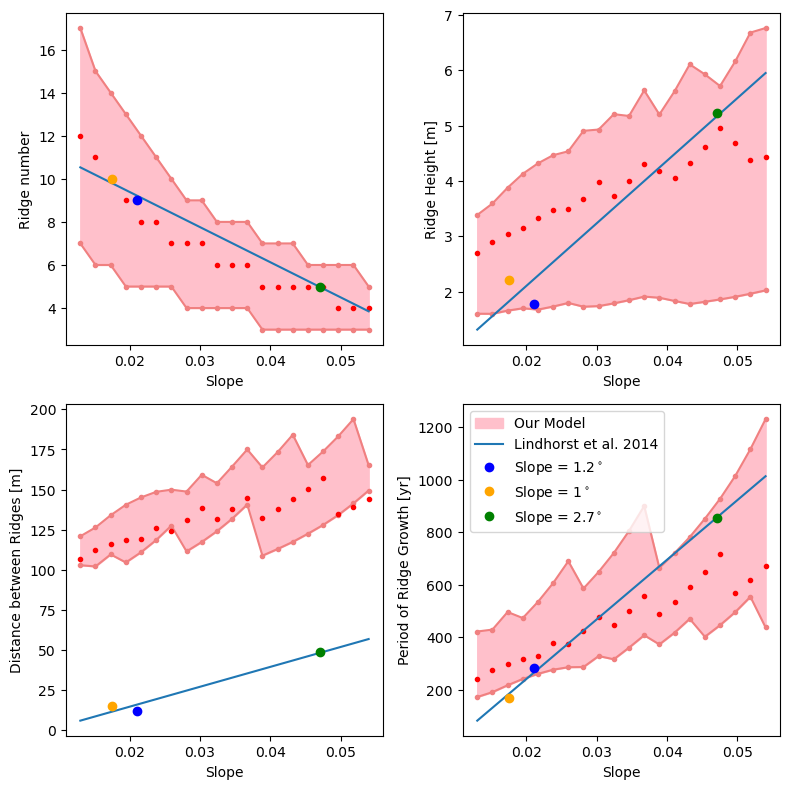

In [28]:
# Lindhorst 2014
a=-.002
Qr=2
Qs=5
Tmax=3000
m=.003
dt=1
b=3
maxH = 20
num = 2
sedqr = [Qr/num,Qr,Qr*num]
sedqs = [Qs/num,Qs,Qs*num]
RSLs = [0,-.002,-.003]
m_vec = np.linspace(.013,.054,20)

analysis = ModelAnalysis(Tmax,dt,a,b,maxH,Qr,Qs,m)
analysis.Lindhorst(m_vec,RSLs,sedqr,sedqs)